# Example 21: OpenSees Verification of Time-Domain Site Response

This example compares **pystrata** time-domain site response against **OpenSees**
(via `openseespy`) as an independent reference.  Both codes solve the 1D
wave-propagation problem for the same soil column, input motion, and boundary
conditions.

Two cases are run:

| Case | pystrata | OpenSees | Purpose |
|------|----------|----------|---------|
| Linear-elastic | `TimeDomainCalculator` (linear profile) | `ElasticIsotropic` + `quad` | Validate integration & boundary |
| Nonlinear (hyperbolic) | `TimeDomainCalculator` (MKZ β=1, s=1) | `PressureIndependMultiYield` | Validate constitutive + nonlinear integration |

**Profile**: 20 m uniform soil (Vs = 200 m/s, ξ = 2 %) over elastic rock
(Vs = 800 m/s).  Discretized into 10 sub-layers (dz = 2 m).

**Input**: Ricker wavelet (f₀ = 3 Hz) applied as an outcrop motion at the base
with a Lysmer–Kuhlemeyer absorbing boundary.

**Damping**: Rayleigh damping in both codes, targeting the same two frequencies
(0.5 Hz and 20 Hz).

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

import pystrata
from pystrata.constitutive import MKZParams, MultiLayerParams
from pystrata.opensees_helpers import run_opensees_linear, run_opensees_nonlinear

%matplotlib inline
plt.rcParams["figure.dpi"] = 120

## Profile and Motion Setup

A single uniform soil layer over rock, discretized into 10 sub-layers.
The Ricker wavelet has its energy concentrated around 3 Hz — well within
the resolution of the 2 m elements (f_max ≈ Vs / (4·dz) = 25 Hz).

In [ ]:
GRAVITY = 9.81

# Profile parameters
n_sub = 10  # sub-layers
vs_soil = 200.0  # m/s
unit_wt_soil = 18.0  # kN/m³
damping_soil = 0.02  # 2 %
vs_base = 800.0  # m/s
unit_wt_base = 24.0  # kN/m³

rho_soil = unit_wt_soil / GRAVITY * 1000  # kg/m³
rho_base = unit_wt_base / GRAVITY * 1000
G_soil = rho_soil * vs_soil**2
dz = 20.0 / n_sub

# Build pystrata Profile: uniform linear soil over elastic rock
soil_type = pystrata.site.SoilType(
    "Soil",
    unit_wt=unit_wt_soil,
    mod_reduc=None,
    damping=damping_soil,
)
rock_type = pystrata.site.SoilType(
    "Rock",
    unit_wt=unit_wt_base,
    mod_reduc=None,
    damping=0.01,
)

profile = pystrata.site.Profile(
    [
        pystrata.site.Layer(soil_type, thickness=dz, shear_vel=vs_soil)
        for _ in range(n_sub)
    ]
    + [pystrata.site.Layer(rock_type, thickness=0, shear_vel=vs_base)]
)

# Arrays for OpenSees helpers (which take raw arrays)
thicknesses = np.array([layer.thickness for layer in profile[:-1]])
densities = np.array([layer.density for layer in profile[:-1]])
shear_mods = np.array([layer.initial_shear_mod for layer in profile[:-1]])
damping_ratios = np.array([layer.damping_min for layer in profile[:-1]])

print(f"Soil: Vs={vs_soil} m/s, G={G_soil / 1e6:.1f} MPa, ρ={rho_soil:.0f} kg/m³")
print(f"Rock: Vs={vs_base} m/s, ρ={rho_base:.0f} kg/m³")
print(f"Sub-layers: {n_sub} × {dz:.1f} m")
print(f"f_max ≈ Vs/(4·dz) = {vs_soil / (4 * dz):.0f} Hz")

Soil: Vs=200.0 m/s, G=73.4 MPa, ρ=1835 kg/m³
Rock: Vs=800.0 m/s, ρ=2446 kg/m³
Sub-layers: 10 × 2.0 m
f_max ≈ Vs/(4·dz) = 25 Hz


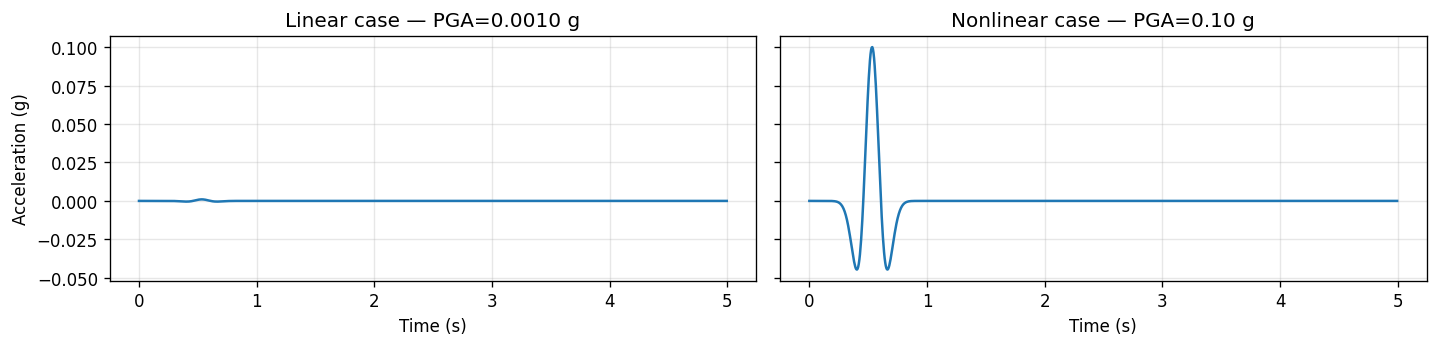

In [20]:
# Ricker wavelet
def make_ricker(f0=3.0, pga=0.001, dt=0.005, dur=5.0):
    t = np.arange(0, dur, dt)
    t0 = 1.0 / f0 + 0.2
    u = (1 - 2 * (np.pi * f0 * (t - t0)) ** 2) * np.exp(-((np.pi * f0 * (t - t0)) ** 2))
    u = u / np.max(np.abs(u)) * pga
    return pystrata.motion.TimeSeriesMotion(
        filename="ricker",
        description="Ricker wavelet",
        time_step=dt,
        accels=u,
    )


motion_lin = make_ricker(f0=3.0, pga=0.001)  # very low PGA for linear case
motion_nl = make_ricker(f0=3.0, pga=0.1)  # moderate PGA for nonlinear case

fig, axes = plt.subplots(1, 2, figsize=(12, 3), sharey=True)
axes[0].plot(motion_lin.times, motion_lin.accels)
axes[0].set(
    xlabel="Time (s)",
    ylabel="Acceleration (g)",
    title=f"Linear case — PGA={motion_lin.pga:.4f} g",
)
axes[1].plot(motion_nl.times, motion_nl.accels)
axes[1].set(xlabel="Time (s)", title=f"Nonlinear case — PGA={motion_nl.pga:.2f} g")
for ax in axes:
    ax.grid(True, alpha=0.3)
fig.tight_layout()

## Case 1: Linear-Elastic Comparison

Both codes use identical elastic properties. The only difference is the
integration scheme:
- **pystrata**: `TimeDomainCalculator` — explicit central-difference with automatic sub-cycling
- **OpenSees**: implicit Newmark (γ=0.5, β=0.25)

In [ ]:
dt = motion_lin.time_step

# --- pystrata linear (via TimeDomainCalculator) ---
calc_lin = pystrata.propagation.TimeDomainCalculator(model="mkz", boundary="elastic")
loc_in = profile.location("outcrop", index=-1)
calc_lin(motion_lin, profile, loc_in)

loc_surf = profile.location("outcrop", index=0)
accel_ps_lin = calc_lin.accel_ts(loc_surf) * GRAVITY  # convert g → m/s²

# --- OpenSees linear ---
input_accel_outcrop = motion_lin.accels * GRAVITY
accel_os_lin = run_opensees_linear(
    thicknesses=thicknesses,
    densities=densities,
    shear_mods=shear_mods,
    damping_ratios=damping_ratios,
    input_accel=input_accel_outcrop,
    dt=dt,
    rho_base=rho_base,
    vs_base=vs_base,
)

print(f"pystrata surface PGA: {np.max(np.abs(accel_ps_lin)):.6f} m/s²")
print(f"OpenSees  surface PGA: {np.max(np.abs(accel_os_lin)):.6f} m/s²")
print(
    f"PGA ratio (pystrata / OpenSees): {np.max(np.abs(accel_ps_lin)) / np.max(np.abs(accel_os_lin)):.3f}"
)

pystrata surface PGA: 0.016547 m/s²
OpenSees  surface PGA: 0.018396 m/s²
PGA ratio (pystrata / OpenSees): 0.899


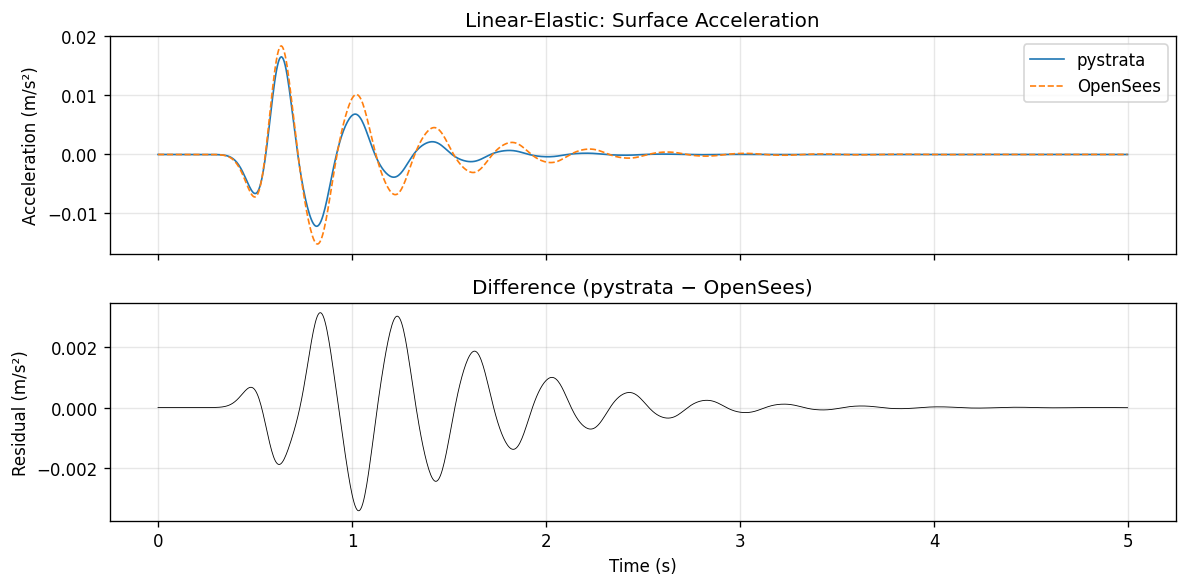

In [ ]:
t_ps = calc_lin.times[: len(accel_ps_lin)]
t_os = np.arange(len(accel_os_lin)) * dt

fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)

axes[0].plot(t_ps, accel_ps_lin, "C0", lw=1, label="pystrata")
axes[0].plot(t_os, accel_os_lin, "C1--", lw=1, label="OpenSees")
axes[0].set(ylabel="Acceleration (m/s²)")
axes[0].legend()
axes[0].set_title("Linear-Elastic: Surface Acceleration")
axes[0].grid(True, alpha=0.3)

# Residual
n = min(len(accel_ps_lin), len(accel_os_lin))
residual = accel_ps_lin[:n] - accel_os_lin[:n]
t_res = np.arange(n) * dt
axes[1].plot(t_res, residual, "k", lw=0.5)
axes[1].set(xlabel="Time (s)", ylabel="Residual (m/s²)")
axes[1].set_title("Difference (pystrata − OpenSees)")
axes[1].grid(True, alpha=0.3)

fig.tight_layout()

In [23]:
# Summary statistics
n = min(len(accel_ps_lin), len(accel_os_lin))
corr = np.corrcoef(accel_ps_lin[:n], accel_os_lin[:n])[0, 1]
rms_diff = np.sqrt(np.mean((accel_ps_lin[:n] - accel_os_lin[:n]) ** 2))
rms_ref = np.sqrt(np.mean(accel_os_lin[:n] ** 2))

pga_ps = np.max(np.abs(accel_ps_lin)) / GRAVITY
pga_os = np.max(np.abs(accel_os_lin)) / GRAVITY

print("=" * 50)
print("Linear-Elastic Comparison Summary")
print("=" * 50)
print(f"Input PGA:              {motion_lin.pga:.4f} g")
print(f"pystrata surface PGA:   {pga_ps:.6f} g")
print(f"OpenSees surface PGA:   {pga_os:.6f} g")
print(f"PGA ratio:              {pga_ps / pga_os:.4f}")
print(f"Waveform correlation:   {corr:.4f}")
print(f"Normalized RMS error:   {rms_diff / rms_ref * 100:.2f} %")

Linear-Elastic Comparison Summary
Input PGA:              0.0010 g
pystrata surface PGA:   0.001687 g
OpenSees surface PGA:   0.001875 g
PGA ratio:              0.8995
Waveform correlation:   0.9846
Normalized RMS error:   25.43 %


## Case 2: Nonlinear (Hyperbolic Backbone) Comparison

Both codes use a hyperbolic backbone τ = G·γ / (1 + γ/γ_ref):
- **pystrata**: `TimeDomainCalculator` with MKZ model (β = 1, s = 1) via explicit `params`
- **OpenSees**: `PressureIndependMultiYield` (PIMY) with cohesion = G·γ_ref

The Ricker wavelet is scaled to PGA = 0.1 g to mobilize nonlinearity.
Both use Rayleigh damping for viscous dissipation.

**Expected differences**: The integration schemes and yield-surface
discretization differ (pystrata uses continuous MKZ, OpenSees uses a
multi-yield-surface approximation with 20 surfaces), so some deviation
is expected — especially in the high-frequency content.

In [ ]:
gamma_ref = 0.01  # reference strain = 1 %
shear_strengths = shear_mods * gamma_ref  # τ_max = G · γ_ref

# Pre-computed MKZ parameters (β=1, s=1 → simple hyperbolic backbone)
n_layers = len(profile) - 1  # exclude halfspace
params = MultiLayerParams()
for i in range(n_layers):
    params.append(
        MKZParams(gamma_ref=gamma_ref, beta=1.0, s=1.0, shear_mod=shear_mods[i])
    )

# --- pystrata nonlinear (via TimeDomainCalculator with explicit params) ---
calc_nl = pystrata.propagation.TimeDomainCalculator(
    model="mkz",
    boundary="elastic",
    damp_form="liu_archuleta",
)
loc_in = profile.location("outcrop", index=-1)
calc_nl(motion_nl, profile, loc_in, params=params)

loc_surf = profile.location("outcrop", index=0)
accel_ps_nl = calc_nl.accel_ts(loc_surf) * GRAVITY  # g → m/s²

# --- OpenSees nonlinear (PIMY) ---
input_accel_outcrop_nl = motion_nl.accels * GRAVITY
accel_os_nl = run_opensees_nonlinear(
    thicknesses=thicknesses,
    densities=densities,
    shear_mods=shear_mods,
    damping_ratios=damping_ratios,
    shear_strengths=shear_strengths,
    ref_strains=np.full(n_layers, gamma_ref),
    input_accel=input_accel_outcrop_nl,
    dt=dt,
    rho_base=rho_base,
    vs_base=vs_base,
)

print(f"pystrata surface PGA: {np.max(np.abs(accel_ps_nl)):.4f} m/s²")
print(f"OpenSees  surface PGA: {np.max(np.abs(accel_os_nl)):.4f} m/s²")
print(
    f"PGA ratio (pystrata / OpenSees): {np.max(np.abs(accel_ps_nl)) / np.max(np.abs(accel_os_nl)):.3f}"
)

pystrata surface PGA: 1.7719 m/s²
OpenSees  surface PGA: 1.8396 m/s²
PGA ratio (pystrata / OpenSees): 0.963


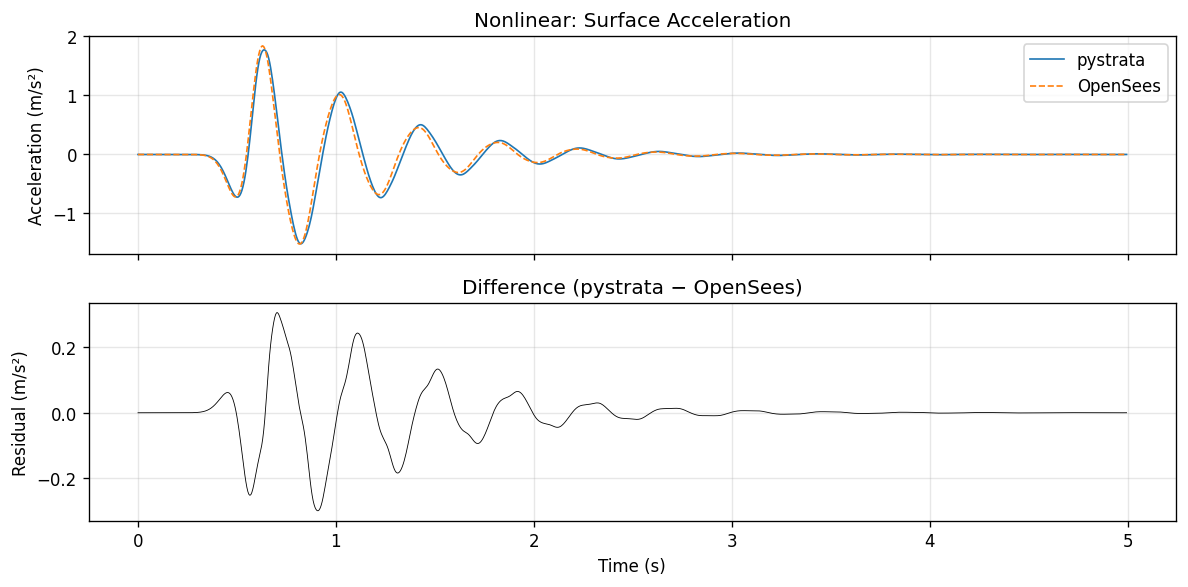

In [ ]:
t_ps_nl = calc_nl.times[: len(accel_ps_nl)]
t_os_nl = np.arange(len(accel_os_nl)) * dt

fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)

axes[0].plot(t_ps_nl, accel_ps_nl, "C0", lw=1, label="pystrata")
axes[0].plot(t_os_nl, accel_os_nl, "C1--", lw=1, label="OpenSees")
axes[0].set(ylabel="Acceleration (m/s²)")
axes[0].legend()
axes[0].set_title("Nonlinear: Surface Acceleration")
axes[0].grid(True, alpha=0.3)

n_nl = min(len(accel_ps_nl), len(accel_os_nl))
residual_nl = accel_ps_nl[:n_nl] - accel_os_nl[:n_nl]
t_res_nl = np.arange(n_nl) * dt
axes[1].plot(t_res_nl, residual_nl, "k", lw=0.5)
axes[1].set(xlabel="Time (s)", ylabel="Residual (m/s²)")
axes[1].set_title("Difference (pystrata − OpenSees)")
axes[1].grid(True, alpha=0.3)

fig.tight_layout()

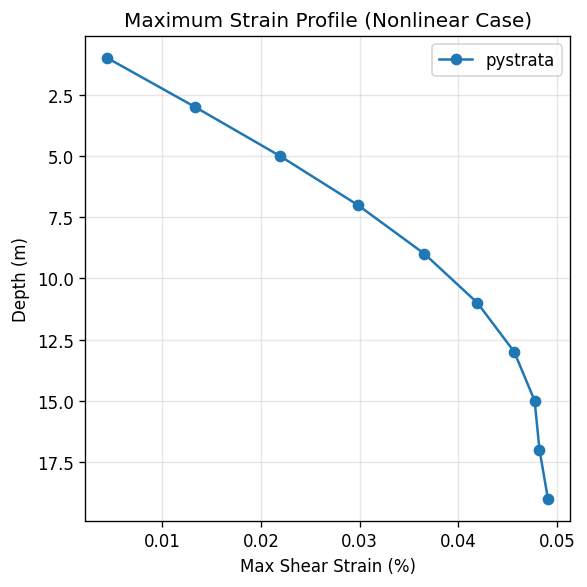

In [ ]:
max_strain_ps = calc_nl.results.max_strain()
mid_depths = np.cumsum(thicknesses) - thicknesses / 2

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(max_strain_ps * 100, mid_depths, "C0o-", label="pystrata")
ax.set(xlabel="Max Shear Strain (%)", ylabel="Depth (m)")
ax.invert_yaxis()
ax.legend()
ax.set_title("Maximum Strain Profile (Nonlinear Case)")
ax.grid(True, alpha=0.3)
fig.tight_layout()

In [27]:
# Nonlinear comparison summary
n_nl = min(len(accel_ps_nl), len(accel_os_nl))
corr_nl = np.corrcoef(accel_ps_nl[:n_nl], accel_os_nl[:n_nl])[0, 1]
rms_diff_nl = np.sqrt(np.mean((accel_ps_nl[:n_nl] - accel_os_nl[:n_nl]) ** 2))
rms_ref_nl = np.sqrt(np.mean(accel_os_nl[:n_nl] ** 2))

pga_ps_nl = np.max(np.abs(accel_ps_nl)) / GRAVITY
pga_os_nl = np.max(np.abs(accel_os_nl)) / GRAVITY

print("=" * 50)
print("Nonlinear Comparison Summary")
print("=" * 50)
print(f"Input PGA:              {motion_nl.pga:.4f} g")
print(f"pystrata surface PGA:   {pga_ps_nl:.4f} g")
print(f"OpenSees surface PGA:   {pga_os_nl:.4f} g")
print(f"PGA ratio:              {pga_ps_nl / pga_os_nl:.4f}")
print(f"Waveform correlation:   {corr_nl:.4f}")
print(f"Normalized RMS error:   {rms_diff_nl / rms_ref_nl * 100:.1f} %")

Nonlinear Comparison Summary
Input PGA:              0.1000 g
pystrata surface PGA:   0.1806 g
OpenSees surface PGA:   0.1875 g
PGA ratio:              0.9632
Waveform correlation:   0.9788
Normalized RMS error:   20.8 %


## Combined Summary

The table below shows how well pystrata matches the OpenSees reference for
both the linear and nonlinear cases.

In [28]:
# Final comparison table
n_lin = min(len(accel_ps_lin), len(accel_os_lin))
n_nl = min(len(accel_ps_nl), len(accel_os_nl))

corr_lin = np.corrcoef(accel_ps_lin[:n_lin], accel_os_lin[:n_lin])[0, 1]
corr_nl = np.corrcoef(accel_ps_nl[:n_nl], accel_os_nl[:n_nl])[0, 1]

pga_ps_lin_g = np.max(np.abs(accel_ps_lin)) / GRAVITY
pga_os_lin_g = np.max(np.abs(accel_os_lin)) / GRAVITY
pga_ps_nl_g = np.max(np.abs(accel_ps_nl)) / GRAVITY
pga_os_nl_g = np.max(np.abs(accel_os_nl)) / GRAVITY

header = f"{'Metric':<25} {'Linear':>12} {'Nonlinear':>12}"
sep = "-" * len(header)
print(header)
print(sep)
print(f"{'Input PGA (g)':<25} {motion_lin.pga:>12.4f} {motion_nl.pga:>12.4f}")
print(f"{'pystrata PGA (g)':<25} {pga_ps_lin_g:>12.6f} {pga_ps_nl_g:>12.4f}")
print(f"{'OpenSees PGA (g)':<25} {pga_os_lin_g:>12.6f} {pga_os_nl_g:>12.4f}")
print(
    f"{'PGA ratio':<25} {pga_ps_lin_g / pga_os_lin_g:>12.4f} {pga_ps_nl_g / pga_os_nl_g:>12.4f}"
)
print(f"{'Waveform correlation':<25} {corr_lin:>12.4f} {corr_nl:>12.4f}")

Metric                          Linear    Nonlinear
---------------------------------------------------
Input PGA (g)                   0.0010       0.1000
pystrata PGA (g)              0.001687       0.1806
OpenSees PGA (g)              0.001875       0.1875
PGA ratio                       0.8995       0.9632
Waveform correlation            0.9846       0.9788
